In [1]:
try:
    import smolgp
except ImportError:
    %pip install -q smolgp

try:
    import tinygp
except ImportError:
    %pip install -q tinygp

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import make_smoothing_spline

key = jax.random.PRNGKey(0)
jax.config.update("jax_enable_x64", True)
mpl.rc('font', family='sans serif', size=16)


(integrated)=

# Integrated Measurements

Observations in astronomy are frequently made over finite time intervals. Such is the case of a CCD pixel accumulating photoelectrons during an exposure. The resulting image (or quantity derived from that image) represents the average of that signal during the exposure. If that signal is stochastic, and especially if the length of the exposure is an appreciable fraction or more of the process timescale, the integration itself is averaging a random snapshot of a random process and so modeling the process with a GP requires correctly computing these integrated covariances.

One of the major advances of `smolgp` over existing tools is its abiltiy to solve the GP regression problem for integrated observations in $O(N)$ time. In fact, it is also compatible with the parallel methods described in {ref}`parallel`. To see how, let's generate an example dataset of two different instruments with different exposure lengths measuring the radial velocity of solar-type oscillations (well modeled by a SHO kernel):

In [2]:
## SHO Kernel
S = 2.36
w = 0.0195
Q = 7.63
sigma = jnp.sqrt(S * w * Q)

## Instantaneous kernel for generating data
true_kernel = tinygp.kernels.quasisep.SHO(omega=w, quality=Q, sigma=sigma)
ts = jnp.sort(jax.random.uniform(key, (1000,), minval=0, maxval=1000))
true_gp = tinygp.GaussianProcess(true_kernel, ts)

## Generate true signal
def get_true_gp(tmin, tmax, dt=1):
    t = jnp.arange(tmin, tmax, dt)
    true_gp = tinygp.GaussianProcess(true_kernel, t)
    y_sample = true_gp.sample(key=jax.random.PRNGKey(32)) 
    f = make_smoothing_spline(t, y_sample, lam=10/60)
    return t, f

tmin, tmax = 0., 3600.
t_true, f = get_true_gp(tmin, tmax, dt=1)

# Function to compute the mean of the signal over an exposure time
def make_exposure(tmid, texp):
    t_in_exp = jnp.linspace(tmid-texp/2, tmid+texp/2, 100)
    return jnp.mean(f(t_in_exp))

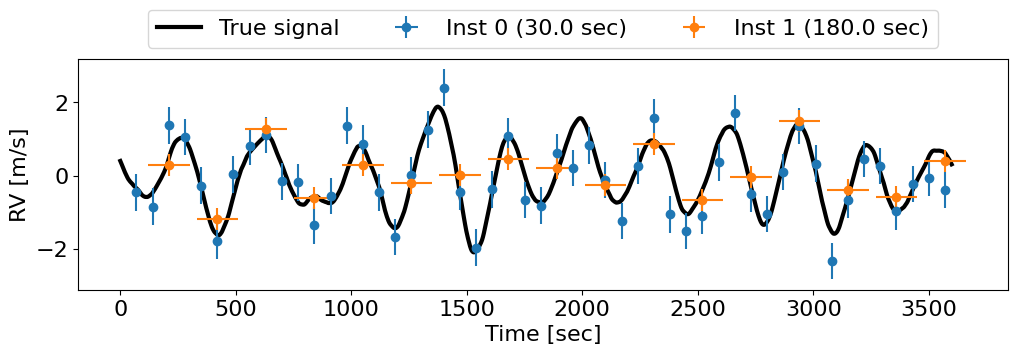

In [3]:
# Generate mock data for two instruments
Ninsts = 2
texps = [30., 180.]
readouts = [40., 30.]
yerrs = [0.5, 0.3]
ts = []
ys = []
for texp, readout, yerr in zip(texps, readouts, yerrs):
    cadence = texp + readout
    t = jnp.arange(tmin + cadence, tmax, cadence)
    y_true = jnp.array([make_exposure(tmid, texp) for tmid in t])
    y = y_true + jax.random.normal(key, t.shape) * yerr
    ts.append(t)
    ys.append(y)

texps = [jnp.full_like(t, texp) for t, texp in zip(ts, texps)]
yerrs = [jnp.full_like(t, yerr) for t, yerr in zip(ts, yerrs)]

fig, ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(t_true, f(t_true), label='True signal', color='k', lw=3)

for instid in range(Ninsts):
    ax.errorbar(ts[instid], ys[instid],
                xerr=texps[instid]/2, yerr=yerrs[instid], fmt='o', 
                label=f'Inst {instid} ({texps[instid][0]} sec)')

ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1))
ax.set(ylabel='RV [m/s]', xlabel='Time [sec]');


Notice how oftentimes the two instruments are exposing at the same time. In other words, the observations here often _overlap_.

## In the traditional GP framework

In the traditional GP framework, we must compute the integrated covariance between pairs of exposures,

\begin{align}
k_{FF}(t_1,t_2,\delta_1,\delta_2) = \frac{1}{\delta_1 \delta_2} \int_{t_1-\delta_1/2}^{t_1+\delta_1/2} \int_{t_2-\delta_2/2}^{t_2+\delta_2/2} k(t,t') \mathrm{d}t \mathrm{d}t'. 
\end{align}

where exposure 1 is centered at time $t_1$ with exposure length $\delta_1$ and exposure 2 is centered at time $t_2$ with exposure length $\delta_2$.

If the exposures do overlap, or if the exposure time varies from measurement to measurement, then the full covariance matrix must be constructed. [Luhn et al. (2026)](https://arxiv.org/abs/2601.02462) worked out the equations for this general case, which for the SHO kernel we have implemented in the `smolgp.kernels.dense.IntegratedSHOKernel` class and can be used with `tinygp`. However, GP regression with a kernel of this form forfeits any quasiseparability the original (unintegrated) kernel may have enjoyed, resulting in $\mathcal{O}(N^3)$ performance.

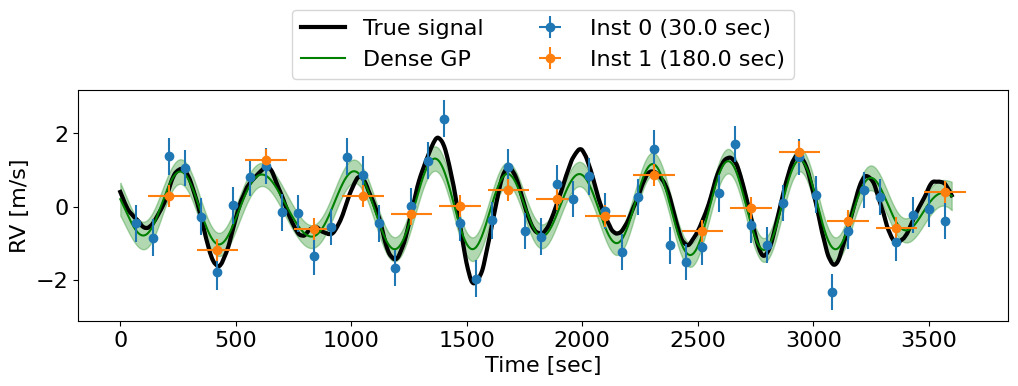

In [4]:
# Create instrument IDs for each set of observations
# These must be integers 0, 1, ..., num_instruments-1
instids = [jnp.full_like(ts[i], i).astype(int) for i in range(Ninsts)]

# Data coordinates for the GP
t_train = jnp.concatenate(ts)
y_train = jnp.concatenate(ys)
texp_train = jnp.concatenate(texps)
inst_train = jnp.concatenate(instids)
yerr_train = jnp.concatenate(yerrs)

X = (t_train, texp_train, inst_train)

# Use tinygp to fit the integrated SHO kernel
sho_dense = smolgp.kernels.dense.IntegratedSHOKernel(S=S, w=w, Q=Q)
gp_dense = tinygp.GaussianProcess(sho_dense, X, diag=yerr_train)

# Predict at test points using zero exposure time and instrument ID 0 
# (the choice of instrument ID doesn't matter here)
X_test = (t_true, jnp.full_like(t_true, 0), jnp.full_like(t_true, 0).astype(int))
mu, var = gp_dense.predict(y_train, X_test, return_var=True)

# Plot
fig, ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(t_true, f(t_true), label='True signal', color='k', lw=3)
ax.plot(t_true, mu, color='green', label='Dense GP')
ax.fill_between(t_true, mu - jnp.sqrt(var), 
                mu + jnp.sqrt(var), color='green', alpha=0.3)
for instid in range(Ninsts):
    ax.errorbar(ts[instid], ys[instid],
                xerr=texps[instid]/2, yerr=yerrs[instid], fmt='o', 
                label=f'Inst {instid} ({texps[instid][0]} sec)')

ax.legend(ncol=2, loc='lower center', bbox_to_anchor=(0.5, 1))
ax.set(ylabel='RV [m/s]', xlabel='Time [sec]');


## In the state space framework

In the state space language, we can state this problem as having a measurement model of the form

\begin{align}
y_k = \frac{1}{\delta_k} \int_{t_k - \delta_k/2}^{t_k + \delta_k/2} f(t) dt + \epsilon_k,
\end{align}

where $\delta_k$ is the length of our exposure centered at time $t_k$. We implement this by augmenting the state vector with the integral state $z$, defined by $\frac{dz}{dt} = x$, and define a state space model over this augmented state $\tilde{\boldsymbol{x}} = (\boldsymbol{x}; z) = (x, \dot{x}, \dots, z)$,


```{math} 
:label: augmented_sde
\frac{\mathrm{d} \tilde{\boldsymbol{x}}}{\mathrm{d} t} = \tilde{\boldsymbol{F}} \tilde{\boldsymbol{x}}(t) + \tilde{\boldsymbol{L}} \boldsymbol{w}(t),
```

where we now have the augmented feedback matrix $\tilde{\boldsymbol{F}} = \begin{pmatrix} \boldsymbol{F} & 0 \\ \boldsymbol{I} & 0 \end{pmatrix}$ and augmented noise effect matrix $\tilde{\boldsymbol{L}} = \begin{pmatrix} \boldsymbol{L} \\ 0 \end{pmatrix}$. This definition encodes in {eq}`augmented_sde` the usual state space SDE $\frac{d\boldsymbol{x}}{dt} = \boldsymbol{F} \boldsymbol{x} + \boldsymbol{L} w$ as well as the definition of the integral state $\frac{dz}{dt} = x$. The augmented model can then be solved with the usual Kalman/RTS algorithms using an augmented observation model which picks out the integral state, e.g. for the SHO
\begin{align}
    \tilde{\boldsymbol{H}}_n = \frac{1}{\delta_n} \begin{pmatrix} 0 & 0 & 1\end{pmatrix}.
\end{align}
To have the integral state represent the integrated state over an exposure, the last implementation piece we need is a way to "reset" the integral state back to zero at exposure starts. This is achieved with the `reset_matrix` attribute of a `StateSpaceModel`, which is applied only at exposure starts during the Kalman/RTS algorithms.

:::{admonition} For multiple instruments
:class: note

When we have multiple instruments, we augment an integral state $z_i$ for each instrument. The reset matrix only resets the integral state belonging to that exposure-start state's instrument. This construction solves the issue of overlapping exposures and doesn't change the Kalman/RTS procedure! Hence, we get $\mathcal{O}(N)$ scaling.

In `smolgp`, this means assigning an instrument ID (integer in $[0, N_{inst}-1]$) to each measurement which the reset matrix uses to zero-out the correct integral state.
:::

:::{admonition} For data with large gaps
:class: warning dropdown

By default, the augmented transition matrix and process noise matrix (which each depend on integrals of their unaugmented counterparts) are generated automatically using the numerical method of [Van Loan (1978)](https://ecommons.cornell.edu/items/cba38b2e-6ad4-45e6-8109-0a019fe5114c). For $\Delta$ around $\sim$$10^3$ times longer than the kernel timescale, the numerical value in the matrix exponential is too large to be represented numerically. Even though we reset the integral state once the next exposure is reached, other instruments which have yet to be reset will contribute to this numerical instability, resulting in NaN values.

If your data have gaps like this (e.g. day-night gaps in an asteroseismic timeseries with fast ($< 1$ hour) oscillations), the only remedy at the moment is to implement the integrated transition matrix and integrated process noise matrix for your kernel of interest analytically. This is only done so far for the SHO kernel (see Appendix B in [Rubenzahl et al. (2026)](https://arxiv.org/abs/2601.02527) for the derviations), though in the future we may implement the same for the other kernels defined in `smolgp`.
:::

Let's build the same model as before, now with `smolgp`. Like before, the data coordinates need to be a tuple of the exposure midpoint time, the exposure length, and the instrument ID (if multiple instruments). Then we build a model just as before and condition/predict with the same function calls. When we predict, we predict the latent (instantaneous) state. Predicting at a new time integrated over a new exposure length is not currently implemented.

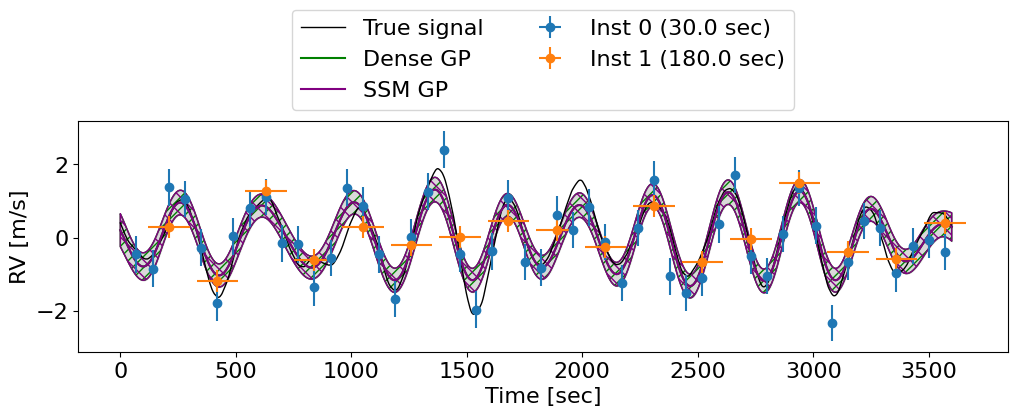

In [5]:
# We have to specify the number of instruments for the SSM kernel upfront,
# since it needs to know how many integral states to create
sho_ssm = smolgp.kernels.IntegratedSHO(sigma=sigma, omega=w, quality=Q, num_insts=Ninsts)
gp_ssm = smolgp.GaussianProcess(sho_ssm, X, diag=yerr_train)

# Predict at test points using zero exposure time and instrument ID 0 
# (the choice of instrument ID doesn't matter here)
X_test = (t_true, jnp.full_like(t_true, 0), jnp.full_like(t_true, 0).astype(int))
mu_ssm, var_ssm = gp_ssm.predict(X_test, y_train, return_var=True)

# Plot
fig, ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(t_true, f(t_true), label='True signal', color='k', lw=1)
ax.plot(t_true, mu, color='green', label='Dense GP')
ax.plot(t_true, mu_ssm, color='purple', label='SSM GP')
ax.fill_between(t_true, mu - jnp.sqrt(var), mu + jnp.sqrt(var), color='green', alpha=0.1)
ax.fill_between(t_true, mu_ssm - jnp.sqrt(var_ssm), mu_ssm + jnp.sqrt(var_ssm), color='purple', alpha=0.1)
ax.fill_between(t_true, mu - jnp.sqrt(var), mu + jnp.sqrt(var), color='none', edgecolor='green', hatch='///')
ax.fill_between(t_true, mu_ssm - jnp.sqrt(var_ssm), mu_ssm + jnp.sqrt(var_ssm), color='none', edgecolor='purple', hatch='\\\\')
for instid in range(Ninsts):
    ax.errorbar(ts[instid], ys[instid],
                xerr=texps[instid]/2, yerr=yerrs[instid], fmt='o', 
                label=f'Inst {instid} ({texps[instid][0]} sec)')

ax.legend(ncol=2, loc='lower center', bbox_to_anchor=(0.5, 1))
ax.set(ylabel='RV [m/s]', xlabel='Time [sec]');


We can see that both methods give the exact same posterior.

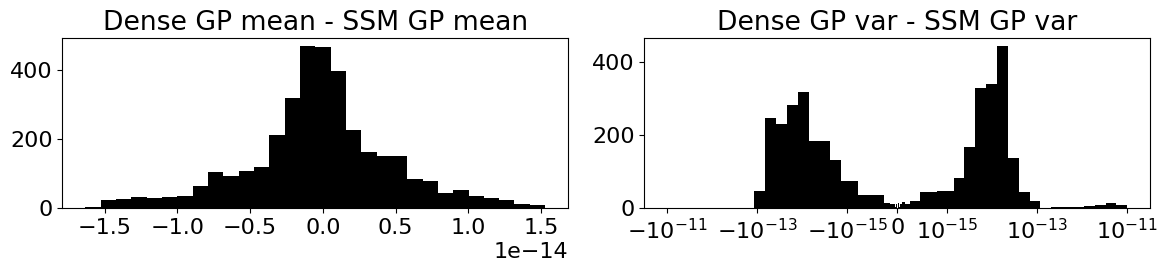

In [6]:
# Variances in tinygp include a small numerical jitter term for stability, 
# so we need to subtract that off before comparing to the SSM GP variances
offset = jnp.sqrt(jnp.finfo(jnp.array(0.)).eps) # machine epsilon
fig, axes = plt.subplots(1,2,figsize=(12,3))
axes[0].hist(mu - mu_ssm, bins=30, color='k')
logbins = jnp.logspace(-18,-11,30)
symlogbins = jnp.concatenate((-logbins[::-1], logbins))
axes[1].hist(var - var_ssm - offset, bins=symlogbins, color='k')
axes[0].set(title='Dense GP mean - SSM GP mean')
axes[1].set(title='Dense GP var - SSM GP var')
axes[1].set_xscale('symlog', linthresh=1e-15)
fig.tight_layout()

To see how the two approaches compare each other as the size of the data array increases, see {ref}`benchmarks`.

## Integrating a custom kernel

Most of the kernels implemented in `smolgp.kernels.base` have an integrated counterpart (with the name "Integrated" prepended) in `smolgp.kernels.integrated`. With the exception of the `IntegratedSHO` (which is defined analytically), these are all simply wrappers that numerically integrate their standard definition.

| Kernel name | Integrated kernel name |
|-------------|------------------------|
| `SHO` | `IntegratedSHO` | 
| `Exp` | `IntegratedExp` | 
| `Matern32` | `IntegratedMatern32` | 
| `Matern52` | `IntegratedMatern52` | 
| `Cosine` | `IntegratedCosine`  | 

To define an integrated kernel for a custom kernel you have defined, you can similarly create an instance of `IntegratedStateSpaceModel`. Say your kernel is called `CustomKernel` and has parameters `param1` and `param2`. Then:

In [9]:
from tinygp.helpers import JAXArray
from smolgp.kernels.integrated import IntegratedStateSpaceModel

class CustomKernel(smolgp.kernels.StateSpaceModel):
    def __init__(self, param1: JAXArray | float, param2: JAXArray | float):
        self.param1 = param1
        self.param2 = param2
    # Define the state-space representation of the kernel here
    # This will depend on the specific kernel you want to implement
    # See the "Defining Kernels" tutorial for more details

class IntegratedCustomKernel(IntegratedStateSpaceModel):
    param1: JAXArray | float
    param2: JAXArray | float

    def __init__(
        self,
        param1: JAXArray | float,
        param2: JAXArray | float,
        num_insts: int = 1,
        name: str = "IntegratedCustomKernel",
        **kwargs,
    ):
        self.param1 = param1
        self.param2 = param2
        self.name = name
        self.num_insts = num_insts
        self.base_model = CustomKernel(param1=param1, param2=param2)

To define an integrated state space model analytically (necessary, if your data have large gaps, to avoid numerical instabilities--see warning above!), you must define an `integrated_transition_matrix` ($\bar{\boldsymbol{\Phi}}$) and `integrated_process_noise` function. The former is the integral over each element[^1] of the transition matrix,
\begin{align}
\bar{\boldsymbol{\Phi}}(\Delta) = \int_0^\Delta \boldsymbol{\Phi}(t) \mathrm{d}t
\end{align}
and the latter is a collection of integrals that return three submatrices used in assembling the augmented process noise: `Qaug12`, `Qaug21`, and `Qaug22` defined respectively as
\begin{align}
 \tilde{\boldsymbol{Q}}_{12} &\equiv \text{first column of}\; \int_0^\Delta \boldsymbol{\Phi}(t) \boldsymbol{L} \boldsymbol{Q}_c \boldsymbol{L}^T \bar{\boldsymbol{\Phi}}(t)^T \mathrm{d} t, \\
\tilde{\boldsymbol{Q}}_{22} &\equiv\text{first element of}\; \int_0^\Delta \bar{\boldsymbol{\Phi}}(t) \boldsymbol{L} \boldsymbol{Q}_c \boldsymbol{L}^T \bar{\boldsymbol{\Phi}}(t)^T \mathrm{d} t.
\end{align}
and $\tilde{\boldsymbol{Q}}_{21} = \tilde{\boldsymbol{Q}}_{12}^T$.

The `IntegratedStateSpaceModel` parent class will handle assembling the augmented matrices for you.

[^1]: Technically, you only need to integrate the first row of the transition matrix, but the array returned by `integrated_transition_matrix` needs to have the same shape as the transition matrix (e.g., you could pad with zeros). In other words, only `self.integrated_transition_matrix(t1,t2)[0,:]` is used in assembling the augmented transition matrix.